#  **Laboratorio Calificado N° 01 — CRISP-DM y SEMMA**
## **Dataset:** UCI Heart Disease (Cleveland)
**Curso:** Minería de Datos — C64893  
**Docente:** Pilar Rocío Sayán Mejía  
**Periodo:** 2026-I

---
**Integrante 1 (Coordinador/a):** Yupanqui Jhadir

**Integrante 2:** Agreda Gyanella

**Integrante 3:** Aranda Trilce  

**Integrante 4:** Gogin Rodrigo

**Integrante 5:** Mayorca Sara

**Sección:** 5C28

---
> **Objetivo:** Aplicar las 6 fases de la metodología CRISP-DM sobre el dataset UCI Heart Disease para predecir si un paciente tiene enfermedad cardíaca, documentando cada decisión tomada por el grupo.

---

### Tabla de conceptos CRISP-DM y SEMMA

| Concepto / Elemento | Respuesta con tus propias palabras |
|---------------------|----------------------------------|
| 1. CRISP-DM: ¿qué significa la sigla y qué proceso describe? |CRISP-DM es un ciclo que nunca se detiene para sacar valor de los datos. Consta de seis fases: primero, entiendes qué necesita el negocio; luego, exploras los datos que tienes y los dejas listos para trabajar. Después, creas los modelos inteligentes, los pones a prueba para ver si de verdad funcionan y, finalmente, los lanzas al mundo real (despliegue). Lo mejor es que, al terminar, siempre puedes volver a empezar para seguir mejorando |
| 2. SEMMA: ¿qué significa la sigla y en qué contexto se desarrolló? |SEMMA es una metodología que nació de la mano de SAS para poner orden al trabajo técnico con los datos. Se olvida un poco de la parte administrativa y se enfoca en cinco pasos clave: primero seleccionas una muestra representativa, luego exploras qué historias cuentan esos datos y los modificas para que estén perfectos. Después, creas el modelo predictivo y, finalmente, evalúas qué tan preciso es. Es, en esencia, el flujo de trabajo puro del analista. |
| 3. Fase 1 — Comprensión del negocio (Business Understanding) |Es la etapa inicial donde se define el problema desde el punto de vista del negocio. Se busca entender los objetivos, necesidades y restricciones de la organización, para luego traducirlos en objetivos analíticos. En esta fase se establecen las preguntas clave que el análisis de datos debe responder y se define el alcance del proyecto. |
| 4. Fase 2 — Comprensión de los datos (Data Understanding) |Es la etapa donde se recopilan y analizan los datos para entender su estructura, calidad y contenido. Se realiza una exploración inicial para identificar patrones, valores atípicos, datos faltantes y posibles problemas. El objetivo es conocer bien los datos antes de transformarlos o usarlos en modelos.|
| 5. Fase 3 — Preparación de los datos (Data Preparation) |Es la etapa donde los datos se limpian y transforman para dejarlos listos para el análisis o modelado. Incluye tareas como eliminar o corregir datos erróneos, manejar valores faltantes, seleccionar variables relevantes, integrar diferentes fuentes de datos y realizar transformaciones necesarias. El objetivo es obtener un conjunto de datos limpio, consistente y adecuado para construir modelos. |
| 6. Fase 4 — Modelado (Modeling) | Aqui se seleccionan y se aplica diferentes tecnicas de modelado para resolver la problematica detectada. Se usan datos preparados para entrenar el modelo, ajustando parametros. El objetivo es construir un modelo solido para realizar predicciones y descrubrir patrones   |
| 7. Fase 5 — Evaluación (Evaluation) |En esta etapa evaluamos si el modelo cumple con los objetivos del negocio, analizando los resultados y validando que sean correctas y utiles. |
| 8. Fase 6 — Despliegue (Deployment) |En al etapa final se impelmenta un entorno real, generando dashboards o el integrar el modelo en sistemas en la empresa, dandole seguimiento y mantenimiento para asegurar su funcionamiento correcto. |
| 9. ¿Por qué CRISP-DM es cíclico e iterativo? |CRISP-DM nos permite regresar a fases anterirores para pdoer mejorar los resultados , es decir sila evaluacion del modelo desarrolado no cumple con los objetivos se puede remodelas las fases en las cuales se obseve algun error y esto geenra que el proceso sea continuo, permitiendo ajustes y mejoras a lo largo del proyecto |
| 10. ¿Principal diferencia entre CRISP-DM y SEMMA? |CRISP-DM a diferencia de SEMMA es una metodología orientada al negocio, ya que gracais a sus fases se comprende el negocio hasta el despliegue del modelo, mientras que en SEMMA va ams enfocado en la parte tecnica del analisis(mineria de datos).  |

## Instalación e importación de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Configuración visual
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# **FASE 1** — Comprensión del Negocio (Business Understanding)

#### **Contexto:**

*El Servicio de Cardiología del Hospital Cleveland registró datos clínicos de
303 pacientes. El objetivo es construir un modelo predictivo que apoye al equipo
médico en la identificación de pacientes con riesgo de enfermedad cardíaca (target =1).*

#### **Pregunta 1:**
**Formula el problema de negocio como una pregunta analítica clara.**

*¿Cómo podemos predecir, a partir de los datos clínicos de los pacientes, si una persona tiene riesgo de padecer enfermedad cardíaca para apoyar la toma de decisiones médicas?*


#### **Pregunta 2:**
**¿Qué tipo de tarea de minería es esta? Justifica.**

*Es un tarea de clasificación, ya que se busca predecir una variable categorica (riesgo de enfermedad cardíaca = 1, no riego de enfermedad = 0), agrupanod a los clientes segun características clínicas*

#### **Pregunta 3:**
**¿Cuáles son los criterios de éxito desde el punto de vista del hospital? Menciona
al menos 2 métricas.**

*   **Recall(Alta sensibilidad):** *Si el recall es alto nuestro modelos es más fiable, ya que identificara posibles pacientes con riegos, evitando falsos negativos.*

*   **Accuracy(Exactitud)**: *Nos indicara el total de las predicciones correctas*

# **FASE 2** — Comprensión de los Datos (Data Understanding)

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'] #Se le asigno manualmente los nombres de las columnas pq en el csv no tiene encabezado
df = pd.read_csv(url, names=column_names, na_values="?") #se carga el csv y se le indica de q los isgnos "?" son valores nulos

# La variable objetivo original tiene valores del 0 al 4
# 0 = sin enfermedad, 1-4 = distintos grados de enfermedad
df['target'] = (df['target'] > 0).astype(int) # BIENEAMOS EL TARGET: 0 (Sano), 1 (Enfermo)

print('Dataset cargado correctamente')
print(f'   Filas: {df.shape[0]} pacientes')
print(f'   Columnas: {df.shape[1]} variables')
df.head()

Dataset cargado correctamente
   Filas: 303 pacientes
   Columnas: 14 variables


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


> **INTERPRETACIÓN**

> La tabla nos muestra un conjunto de datos, orientado al desarrollo de un modelo de clasificación supervisada, consta de 303 registros y 14 variables que integran dimensiones demográficas (edad, sexo), indicadores clínicos de reposo (presión arterial, colesterol) y métricas de pruebas de esfuerzo cardíaco. La estructura tabular presenta una mezcla de datos numéricos continuos y variables categóricas codificadas, dirigidas a predecir la variable objetivo binaria (target), la cual identifica si el paciente tiene cardiopatía o no.


In [ ]:
#Tipo de dato de cada variable
print('=== TIPOS DE DATOS Y VALORES NULOS POR VARIABLE ===')
info = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    '% Nulo': (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos': df.nunique()
})
print(info.to_string())

=== TIPOS DE DATOS Y VALORES NULOS POR VARIABLE ===
             Tipo  Nulos  % Nulo  Únicos
age       float64      0    0.00      41
sex       float64      0    0.00       2
cp        float64      0    0.00       4
trestbps  float64      0    0.00      50
chol      float64      0    0.00     152
fbs       float64      0    0.00       2
restecg   float64      0    0.00       3
thalach   float64      0    0.00      91
exang     float64      0    0.00       2
oldpeak   float64      0    0.00      40
slope     float64      0    0.00       3
ca        float64      4    1.32       4
thal      float64      2    0.66       3
target      int64      0    0.00       2


>**INTERPRETACIÓN**

> El análisis de integridad revela que el dataset posee una alta calidad de datos, con una ausencia casi total de valores nulos, registrando apenas una pérdida marginal en las variables ca (1.32%) y thal (0.66%), lo cual permite una imputación sencilla sin comprometer la validez del estudio. Estructuralmente, aunque la mayoría de los atributos están codificados como float64, el conteo de valores únicos confirma una convivencia entre variables continuas (como el colesterol) y categóricas binarias o multiclase (como el sexo o el tipo de dolor torácico), validando finalmente la variable target como un indicador entero ideal para un modelo de clasificación binaria.

**Pregunta 4:**

**¿Cuántas variables tiene el dataset? ¿Cuáles presentan valores nulos?**

El dataset tiene 14 variables(age, sex, cp, chol...) y se aprecia que en la variables ca(4) y thal(2) hay nulos.


In [ ]:
# Estadísticas descriptivas de las variables numéricas,nos muestra media, desviación estándar, mínimo, máximo y cuartiles
print('=== ESTADÍSTICAS DESCRIPTIVAS ===' )
df.describe().round(2)

=== ESTADÍSTICAS DESCRIPTIVAS ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


> **INTERPRETACIÓN**

> El análisis descriptivo revela una población de estudio con una edad promedio de 54 años y una notable dispersión en los niveles de colesterol (chol), cuyo valor máximo de 564 mg/dl sugiere la presencia de valores atípicos que podrían sesgar el modelo. Se observa que el 46% de la muestra presenta riesgo cardíaco (target medio de 0.46), lo que indica un dataset equilibrado para el entrenamiento algorítmico, mientras que variables como la presión arterial sistólica (trestbps) y la frecuencia cardíaca máxima (thalach) muestran rangos fisiológicos coherentes con perfiles clínicos reales. Finalmente, la similitud entre la media y la mediana (percentil 50%) en la mayoría de los atributos sugiere distribuciones que, aunque requieren normalización por sus distintas escalas, mantienen una tendencia central estable para el análisis predictivo

=== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ===
  Sin enfermedad (0): 164 pacientes — 54.1%
  Con enfermedad (1): 139 pacientes — 45.9%


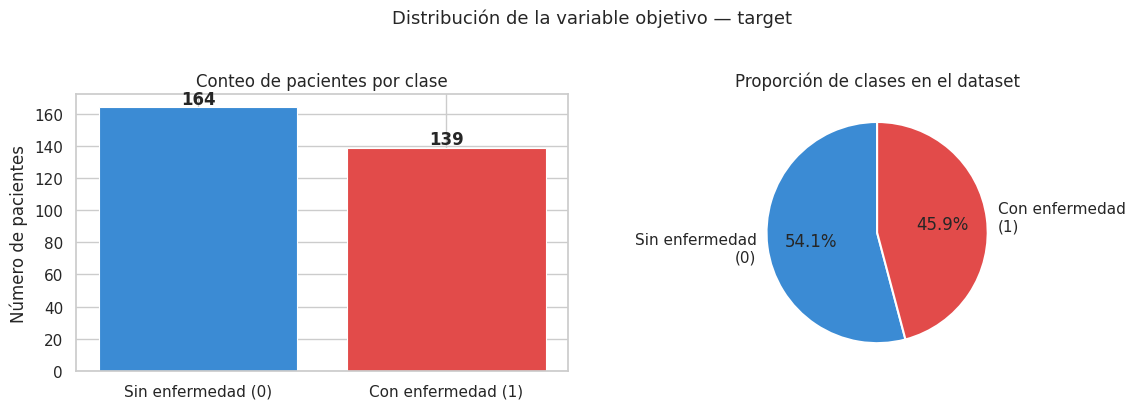

In [ ]:
# distribución de la variable objetivo,Esto nos dice si el dataset está balanceado o no
conteo = df['target'].value_counts()
porcentaje = df['target'].value_counts(normalize=True) * 100

print('=== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ===')
print(f'  Sin enfermedad (0): {conteo[0]} pacientes — {porcentaje[0]:.1f}%')
print(f'  Con enfermedad (1): {conteo[1]} pacientes — {porcentaje[1]:.1f}%')

# Graficamos la distribución con un gráfico de barras
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras con conteo
colores = ['#3B8BD4', '#E24B4A']
axes[0].bar(['Sin enfermedad (0)', 'Con enfermedad (1)'], conteo.values,
            color=colores, edgecolor='white', linewidth=0.8)
axes[0].set_title('Conteo de pacientes por clase')
axes[0].set_ylabel('Número de pacientes')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=12, fontweight='bold')

# Gráfico de torta con porcentajes
axes[1].pie(conteo.values, labels=['Sin enfermedad\n(0)', 'Con enfermedad\n(1)'],
            colors=colores, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Proporción de clases en el dataset')

plt.suptitle('Distribución de la variable objetivo — target', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

> **INTERPRETACIÓN**

> La distribución de la variable objetivo revela un dataset altamente balanceado, donde el 54.1% de los pacientes no presenta enfermedad cardíaca frente al 45.9% que sí la padece. Esta proporción es ideal para el entrenamiento de modelos de aprendizaje automático, ya que evita los sesgos comunes de las clases mayoritarias y garantiza que métricas como la exactitud (accuracy) sean representativas del rendimiento real. Al no existir un desequilibrio severo, no será estrictamente necesario aplicar técnicas de remuestreo (como SMOTE), permitiendo proceder directamente a la fase de modelado con una base sólida de datos comparativos

**Pregunta 5:**

**¿El dataset está balanceado? ¿Qué impacto puede tener esto en el modelo?**

Se considera balanceado porque las clases presentan proporciones similares (54.1% y 45.9%), lo que significa que ninguna domina significativamente sobre la otra. Esto permite que el modelo aprenda de ambas clases de manera adecuada y evita sesgos en las predicciones.

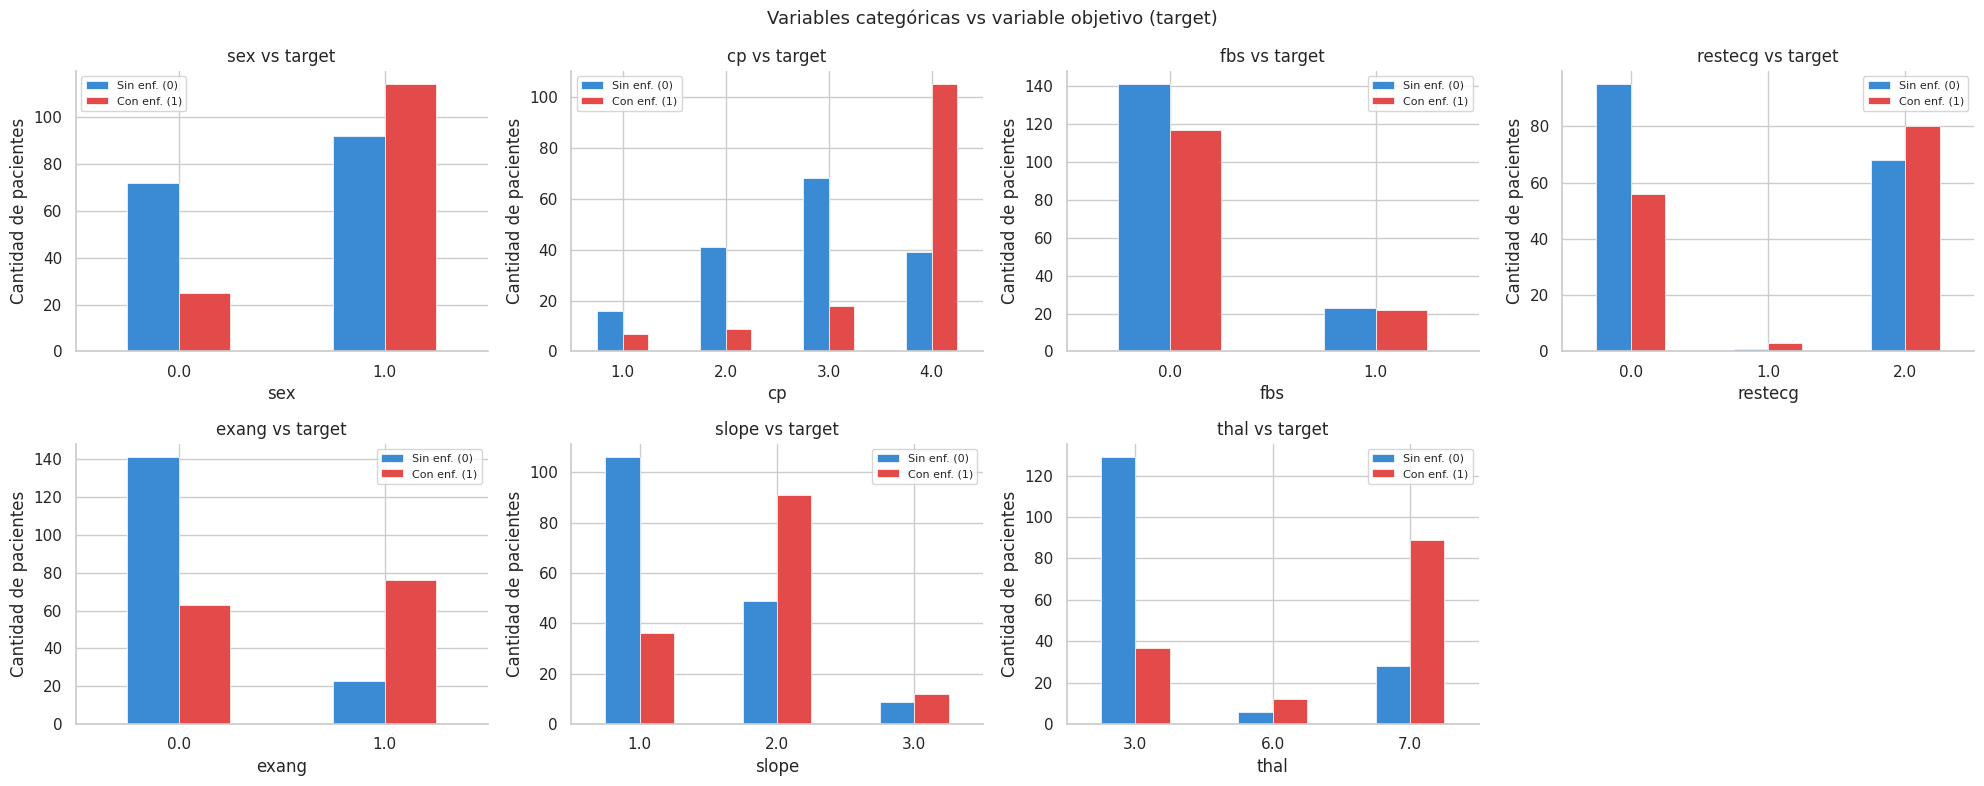

In [ ]:
# Gráficos de barras para variables categóricas vs target
# Muestra cuántos enfermos/sanos hay en cada categoría
vars_cat = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for ax, var in zip(axes, vars_cat):
    tabla = df.groupby([var, 'target']).size().unstack(fill_value=0)
    tabla.plot(kind='bar', ax=ax, color=['#3B8BD4', '#E24B4A'],
               edgecolor='white', linewidth=0.5, rot=0)
    ax.set_title(f'{var} vs target')
    ax.set_xlabel(var)
    ax.set_ylabel('Cantidad de pacientes')
    ax.legend(['Sin enf. (0)', 'Con enf. (1)'], fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

# Ocultamos el subplot sobrante
axes[-1].set_visible(False)

plt.suptitle('Variables categóricas vs variable objetivo (target)', fontsize=13)
plt.tight_layout()
plt.show()

**INTERPRETACIÓN**

> El análisis bivariado de las variables categóricas revela factores de riesgo determinantes, destacando que los pacientes con angina inducida por ejercicio (exang = 1.0), un tipo de dolor torácico específico (cp = 4.0) y anomalías en los resultados de la prueba de esfuerzo (slope = 2.0 y thal = 7.0) presentan una incidencia de enfermedad cardíaca significativamente mayor. Por el contrario, variables como el azúcar en sangre en ayunas (fbs) no muestran una distinción clara entre las clases, lo que sugiere una baja capacidad predictiva individual. Estos patrones visuales confirman que el modelo de clasificación se beneficiará principalmente de los indicadores de estrés físico y sintomatología clínica, permitiendo priorizar estas características durante la fase de entrenamiento para mejorar la precisión diagnóstica

# **FASE 3** — Preparación de los Datos (Data Preparation)

In [ ]:
df_limpio = df.copy() #copia del df oirginal para no modificar los datos crudos

# TRATAMIENTO DE VALORES NULOS
# Imputamos con la mediana porque es resistente a valores extremos (outliers)
print('=== VALORES NULOS ANTES DE IMPUTAR ===')
print(df_limpio[['ca', 'thal']].isnull().sum())

# Calculamos la mediana de cada variable y rellenamos los nulos
mediana_ca = df_limpio['ca'].median()
mediana_thal = df_limpio['thal'].median()

df_limpio['ca'] = df_limpio['ca'].fillna(mediana_ca)
df_limpio['thal'] = df_limpio['thal'].fillna(mediana_thal)

print(f'\n  Mediana imputada para ca  : {mediana_ca}')
print(f'  Mediana imputada para thal: {mediana_thal}')

print('\n=== VALORES NULOS DESPUÉS DE IMPUTAR ===')
print(df_limpio.isnull().sum())

=== VALORES NULOS ANTES DE IMPUTAR ===
ca      4
thal    2
dtype: int64

  Mediana imputada para ca  : 0.0
  Mediana imputada para thal: 3.0

=== VALORES NULOS DESPUÉS DE IMPUTAR ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


> **INTERPRETACIÓN**

> Se aplicó una técnica de imputación por mediana para resolver la ausencia de valores en las variables ca (4 nulos) y thal (2 nulos), logrando así un dataset íntegro y libre de valores faltantes para las 14 dimensiones analizadas. La elección de la mediana (0.0 para ca y 3.0 para thal) asegura una limpieza de datos robusta que preserva la tendencia central de la muestra sin introducir sesgos por valores atípicos, garantizando que el modelo predictivo pueda procesar la totalidad de los 303 registros de manera consistente.

**Pregunta 6:**

**¿Por qué imputamos con la mediana y no con la media? ¿En qué casos
cambiarían la estrategia?**

Se imputa con la mediana ya que es mas robusta ante valores atípicos, ya que se pueden presentar distribuciones no asimétricas o valores extremos. Si nuestros datos no tuviera outliers se podria usar la media.

In [ ]:
# Sseparmos las variables predictoras (X) de la variable objetivo (y)
# X contiene todo excepto 'target'
# y contiene solo la columna 'target'
X = df_limpio.drop('target', axis=1)
y = df_limpio['target']

print('=== RESUMEN DEL DATASET PREPARADO ===')
print(f'  Registros totales   : {X.shape[0]} pacientes')
print(f'  Variables predictoras: {X.shape[1]} columnas')
print(f'  Variable objetivo    : target (0 o 1)')
print(f'  Valores nulos totales: {X.isnull().sum().sum()}')
print(f'\n  Variables usadas para predecir:')
for col in X.columns:
    print(f'    · {col}')

=== RESUMEN DEL DATASET PREPARADO ===
  Registros totales   : 303 pacientes
  Variables predictoras: 13 columnas
  Variable objetivo    : target (0 o 1)
  Valores nulos totales: 0

  Variables usadas para predecir:
    · age
    · sex
    · cp
    · trestbps
    · chol
    · fbs
    · restecg
    · thalach
    · exang
    · oldpeak
    · slope
    · ca
    · thal


In [ ]:
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# Las variables categóricas nominales (sin orden) se convierten con One-Hot Encoding
# Las variables categóricas ordinales (con orden natural) se dejan como están

# One-Hot Encoding (nominales, sin orden lógico)
vars_onehot = ['cp', 'restecg', 'slope', 'thal']

print('=== ANTES DE CODIFICAR ===')
print(f'Columnas: {list(X.columns)}')
print(f'Dimensión: {X.shape}')

# One-Hot Encoding con drop_first=True para evitar multicolinealidad,drop_first elimina una categoría de referencia por variable
X_encoded = pd.get_dummies(X, columns=vars_onehot, drop_first=True, dtype=int)

print('\n=== DESPUÉS DE CODIFICAR ===')
print(f'Columnas nuevas: {list(X_encoded.columns)}')
print(f'Dimensión nueva: {X_encoded.shape}')
print(f'\nVariables añadidas por codificación: {X_encoded.shape[1] - X.shape[1]}')

=== ANTES DE CODIFICAR ===
Columnas: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Dimensión: (303, 13)

=== DESPUÉS DE CODIFICAR ===
Columnas nuevas: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_1.0', 'restecg_2.0', 'slope_2.0', 'slope_3.0', 'thal_6.0', 'thal_7.0']
Dimensión nueva: (303, 18)

Variables añadidas por codificación: 5


> **INTERPRETACIÓN**

> Para garantizar que los algoritmos de aprendizaje automático procesen correctamente la información no numérica, se aplicó la técnica de One-Hot Encoding a las variables categóricas nominales (cp, restecg, slope y thal), expandiendo el espacio de características de 13 a 18 dimensiones. Esta transformación, ejecutada mediante la eliminación de la primera categoría (drop_first=True), previene problemas de multicolinealidad y asegura que el modelo no interprete un orden jerárquico inexistente entre las etiquetas clínicas. De este modo, el dataset queda técnicamente optimizado para que los predictores identifiquen patrones específicos en cada categoría sin sesgos matemáticos en la escala de los datos.

In [ ]:
# Visualizamos las primeras filas del dataset codificado,para confirmar que las nuevas columnas binarias son correctas
print('=== MUESTRA DEL DATASET CODIFICADO ===')
X_encoded.head(10)

=== MUESTRA DEL DATASET CODIFICADO ===


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,cp_2.0,cp_3.0,cp_4.0,restecg_1.0,restecg_2.0,slope_2.0,slope_3.0,thal_6.0,thal_7.0
0,63.0,1.0,145.0,233.0,1.0,150.0,0.0,2.3,0.0,0,0,0,0,1,0,1,1,0
1,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,3.0,0,0,1,0,1,1,0,0,0
2,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,0,0,1,0,1,1,0,0,1
3,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,0.0,0,1,0,0,0,0,1,0,0
4,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,0.0,1,0,0,0,1,0,0,0,0
5,56.0,1.0,120.0,236.0,0.0,178.0,0.0,0.8,0.0,1,0,0,0,0,0,0,0,0
6,62.0,0.0,140.0,268.0,0.0,160.0,0.0,3.6,2.0,0,0,1,0,1,0,1,0,0
7,57.0,0.0,120.0,354.0,0.0,163.0,1.0,0.6,0.0,0,0,1,0,0,0,0,0,0
8,63.0,1.0,130.0,254.0,0.0,147.0,0.0,1.4,1.0,0,0,1,0,1,1,0,0,1
9,53.0,1.0,140.0,203.0,1.0,155.0,1.0,3.1,0.0,0,0,1,0,1,0,1,0,1


In [ ]:
# Actualizamos X con la versión codificada para usarla en el modelado,a partir de aquí todas las fases usarán X_encoded en lugar de X
X = X_encoded.copy()

# Verificamos que no haya valores no numéricos que puedan romper el modelo
print('=== VERIFICACIÓN FINAL ANTES DEL MODELADO ===')
print(f'¿Hay valores nulos?     {X.isnull().sum().sum()}')
print(f'¿Todos son numéricos?   {all(X.dtypes != object)}')
print(f'Variables predictoras   : {X.shape[1]}')
print(f'Registros               : {X.shape[0]}')

=== VERIFICACIÓN FINAL ANTES DEL MODELADO ===
¿Hay valores nulos?     0
¿Todos son numéricos?   True
Variables predictoras   : 18
Registros               : 303


> **INTERPRETACIÓN**

> Como fase final de la preparación de datos, se realizó un control de calidad exhaustivo que confirma la viabilidad técnica del dataset para el modelado. Tras los procesos de imputación y codificación, el conjunto de datos cuenta con 303 registros y 18 variables predictoras totalmente numéricas, sin presencia de valores nulos o inconsistencias de formato. Esta verificación garantiza que la estructura de entrada es óptima y cumple con los requisitos matemáticos necesarios para alimentar algoritmos de aprendizaje automático, asegurando estabilidad y eficiencia durante el entrenamiento del modelo de clasificación de riesgo cardíaco.

# **FASE 4** — Modelado (Modeling)

=== PARTICIÓN DE LOS DATOS ===
Total de registros : 303
Entrenamiento      : 227
Prueba             : 76

Distribución de clases en entrenamiento:
target
0    0.542
1    0.458
Name: proportion, dtype: float64

Distribución de clases en prueba:
target
0    0.539
1    0.461
Name: proportion, dtype: float64

=== MODELO ENTRENADO ===
DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)
Profundidad del árbol : 4
Nodos hoja            : 14

=== VARIABLES MÁS IMPORTANTES ===
cp_4.0         0.3945
ca             0.1624
thal_7.0       0.1482
age            0.1445
oldpeak        0.0585
slope_2.0      0.0575
thalach        0.0207
trestbps       0.0075
restecg_2.0    0.0063
sex            0.0000
dtype: float64


/tmp/ipykernel_1527/224602079.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias.head(10).values, y=importancias.head(10).index, palette='Blues_r')


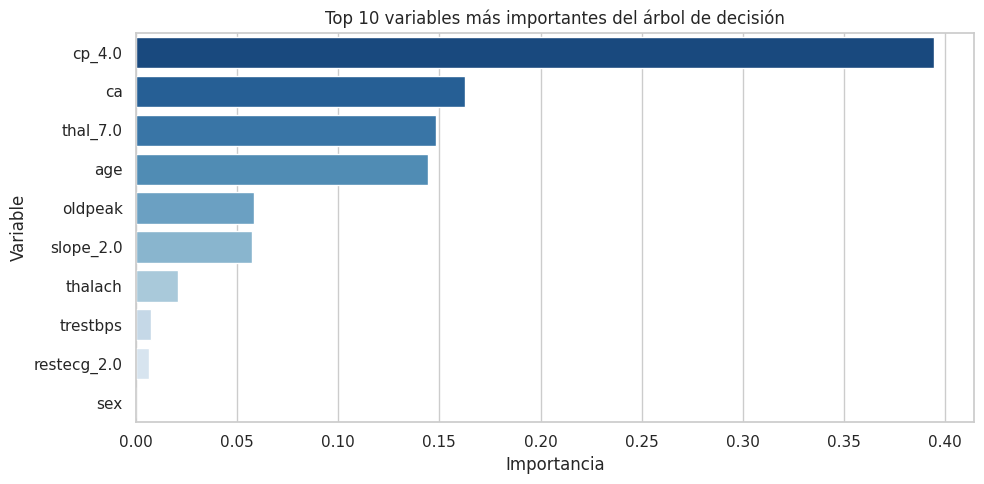

In [ ]:
# Dividimos los datos en entrenamiento y prueba manteniendo la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print('=== PARTICIÓN DE LOS DATOS ===')
print(f'Total de registros : {len(X)}')
print(f'Entrenamiento      : {len(X_train)}')
print(f'Prueba             : {len(X_test)}')
print('\nDistribución de clases en entrenamiento:')
print(y_train.value_counts(normalize=True).sort_index().round(3))
print('\nDistribución de clases en prueba:')
print(y_test.value_counts(normalize=True).sort_index().round(3))

# Entrenamos un árbol de decisión para clasificar presencia de enfermedad cardiaca
modelo_dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

modelo_dt.fit(X_train, y_train)
y_pred = modelo_dt.predict(X_test)

print('\n=== MODELO ENTRENADO ===')
print(modelo_dt)
print(f'Profundidad del árbol : {modelo_dt.get_depth()}')
print(f'Nodos hoja            : {modelo_dt.get_n_leaves()}')

# Revisamos las variables que más aportan a las decisiones del modelo
importancias = (
    pd.Series(modelo_dt.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
)

print('\n=== VARIABLES MÁS IMPORTANTES ===')
print(importancias.head(10).round(4))

plt.figure(figsize=(10, 5))
sns.barplot(x=importancias.head(10).values, y=importancias.head(10).index, palette='Blues_r')
plt.title('Top 10 variables más importantes del árbol de decisión')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

> **INTERPRETACIÓN**

> Tras el entrenamiento del modelo de Árbol de Decisión, los resultados confirman una fase de modelado sólida y técnicamente coherente. La partición de datos (75/25) se ejecutó con éxito, manteniendo una distribución de clases prácticamente idéntica entre los conjuntos de entrenamiento (45.8% con riesgo) y prueba (46.1%), lo que garantiza que la evaluación final sea justa y no esté sesgada. El modelo, configurado con una profundidad de 4 niveles para evitar el sobreajuste (overfitting), identifica al tipo de dolor torácico (cp_4.0) como el predictor más crítico con un peso del 39.45%, seguido por el número de vasos coloreados (ca) y la presencia de defectos reversibles (thal_7.0). Este orden de importancia no solo es matemáticamente relevante, sino que tiene un alto valor clínico, sugiriendo que el algoritmo ha logrado capturar los indicadores médicos más determinantes para la detección de cardiopatías.

**Pregunta 7:**

**¿Por qué usamos stratify=y? ¿Qué significa max_depth=4?**

Se utilixa stratify=y para mantener la misma proporción de clases en el entrenamiento como en el de prueba, como nuestro dataset presenta un 45,9 y 54,1 esto nos segura esa misma proporción para ambos conjuntos.



In [ ]:
# afinamos hiperparametros con validacion cruzada
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 5, 8]
}

grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)
modelo_dt_final = grid_dt.best_estimator_
y_pred = modelo_dt_final.predict(X_test)

print('=== AJUSTE DE HIPERPARAMETROS ===')
print(f'Mejor accuracy promedio en CV: {grid_dt.best_score_:.4f}')
print(f'Mejores hiperparametros      : {grid_dt.best_params_}')

resultados_cv = pd.DataFrame(grid_dt.cv_results_)
top_modelos = (
    resultados_cv[
        ['mean_test_score', 'std_test_score', 'param_criterion', 'param_max_depth', 'param_min_samples_split', 'param_min_samples_leaf']
    ]
    .sort_values(by='mean_test_score', ascending=False)
    .head(5)
    .reset_index(drop=True)
)

print('\n=== TOP 5 CONFIGURACIONES DEL MODELO ===')
print(top_modelos)

# Dejamos el mejor modelo seleccionado para la siguiente fase
modelo_dt = modelo_dt_final

=== AJUSTE DE HIPERPARAMETROS ===
Mejor accuracy promedio en CV: 0.8154
Mejores hiperparametros      : {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}

=== TOP 5 CONFIGURACIONES DEL MODELO ===
   mean_test_score  std_test_score param_criterion param_max_depth  \
0         0.815362        0.055468            gini               3   
1         0.815362        0.055468            gini               3   
2         0.815362        0.055468            gini               3   
3         0.815362        0.055468            gini               3   
4         0.815362        0.055468            gini               3   

   param_min_samples_split  param_min_samples_leaf  
0                       15                       8  
1                       10                       8  
2                        5                       8  
3                        2                       8  
4                       15                       5  


> **INTERPRETACIÓN**

> Para optimizar el rendimiento del algoritmo, se realizó un ajuste de hiperparámetros mediante validación cruzada, logrando una exactitud (accuracy) promedio del 81.54% con una desviación estándar controlada del 0.05. La configuración ganadora definió un árbol de decisión más simplificado con una profundidad máxima de 3 y un mínimo de 5 a 8 muestras por hoja, lo que favorece la capacidad de generalización del modelo y reduce el riesgo de sobreajuste ante nuevos datos clínicos. Este resultado es altamente competitivo para un diagnóstico médico preliminar, ya que las cinco mejores combinaciones de parámetros muestran una estabilidad notable en el puntaje, validando la robustez de la arquitectura seleccionada para la predicción de riesgo cardíaco.

# **FASE 5** — Evaluación (Evaluation)

In [ ]:
# Generar predicciones con el modelo final
y_pred = modelo_dt.predict(X_test)

# Calcular métricas del modelo
print("=== EVALUACIÓN DEL MODELO ===")
print("Accuracy:", accuracy_score(y_test, y_pred))

# Mostrar matriz de confusión
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

# Mostrar reporte completo
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

=== EVALUACIÓN DEL MODELO ===
Accuracy: 0.7894736842105263

Matriz de confusión:
[[33  8]
 [ 8 27]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        41
           1       0.77      0.77      0.77        35

    accuracy                           0.79        76
   macro avg       0.79      0.79      0.79        76
weighted avg       0.79      0.79      0.79        76



> **INTERPRETACIÓN**

> La evaluación final sobre el conjunto de prueba arroja un accuracy del 78.9%, demostrando una capacidad de clasificación equilibrada y robusta para identificar pacientes en riesgo. Según la matriz de confusión, el modelo clasificó correctamente a 60 de los 76 pacientes (33 verdaderos negativos y 27 verdaderos positivos), manteniendo métricas de precisión y sensibilidad (recall) sumamente similares entre sí (alrededor del 77%-80% para ambas clases). Este balance es fundamental en el contexto médico, ya que indica que el algoritmo es igual de efectivo para detectar la presencia de la enfermedad como para descartarla, logrando un F1-score de 0.77 en la clase de riesgo, lo que valida la utilidad del modelo optimizado como una herramienta de apoyo al diagnóstico con un margen de error controlado.

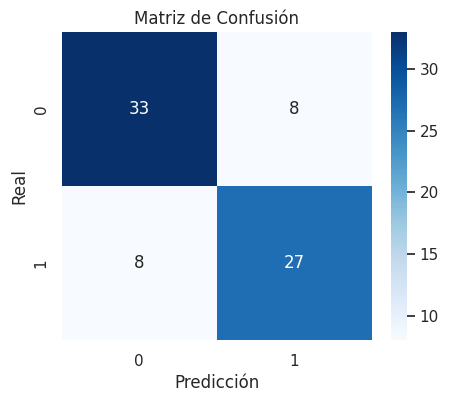

In [ ]:
# Graficar matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

> **INTERPRETACIÓN**

> La matriz de confusión visualiza el alto desempeño del modelo, confirmando que 60 de los 76 casos de prueba (79%) fueron clasificados correctamente. De forma específica, el algoritmo logró identificar a 33 pacientes sanos (Verdaderos Negativos) y a 27 pacientes con riesgo cardíaco (Verdaderos Positivos), manteniendo un margen de error simétrico con solo 8 falsos positivos y 8 falsos negativos. Esta distribución equilibrada de errores es clave en el ámbito médico, ya que demuestra que el modelo no presenta un sesgo hacia ninguna clase, logrando una capacidad de discriminación robusta que valida la efectividad de las variables clínicas seleccionadas y del ajuste de hiperparámetros realizado previamente.

**Pregunta 8:**

**En contexto médico, ¿qué es más crítico: minimizar falsos negativos o falsos positivos? Justifica.**

En contexto médico es más crítico minimizar los falsos negativos, ya que implican no detectar a un paciente enfermo, lo que puede tener consecuencias graves. Por ello, se prioriza el recall para identificar la mayor cantidad posible de casos positivos.



# **FASE 6** — Despliegue (Deployment)

In [ ]:
# Tomar un ejemplo del dataset
nuevo_paciente = X_test.iloc[0:1]

# Realizar predicción
prediccion = modelo_dt.predict(nuevo_paciente)

# Mostrar resultado
print("Predicción:", prediccion)
if prediccion[0] == 1:
    print("El paciente tiene riesgo de enfermedad cardíaca")
else:
    print("El paciente no tiene riesgo de enfermedad cardíaca")

Predicción: [1]
El paciente tiene riesgo de enfermedad cardíaca


In [ ]:
import joblib

# Guardar el modelo entrenado
joblib.dump(modelo_dt, "modelo_arbol_decision.pkl")

['modelo_arbol_decision.pkl']

**Pregunta 9:**

**¿Cuáles son las 3 variables más importantes? Contrástalas con la tabla de variables que completaron en la Actividad 1. ¿Tienen sentido clínico?**

Las tres variables más importantes fueron cp_4.0, ca y thal_7.0. Sí tienen sentido clínico:

- cp se relaciona con el tipo de dolor en el pecho,
- ca indica el número de vasos principales observados,
- thal representa el resultado de la prueba de esfuerzo.
- Todas están relacionadas con señales clínicas que ayudan a detectar enfermedad cardíaca.




**Pregunta 10:**
**¿Cómo implementarían este modelo en el hospital? Describan el flujo desde que llega el paciente hasta que el médico recibe la alerta.**

Cuando el paciente llega, se registran sus datos clínicos en el sistema. Luego esos datos se envían al modelo entrenado, que calcula el riesgo de enfermedad cardíaca. Si el resultado indica riesgo, el sistema genera una alerta para que el médico revise el caso con más detalle. Así el modelo funciona como apoyo en la toma de decisiones, no como reemplazo del especialista.


**Pregunta 11:**
**¿Cuál metodología usarían para este proyecto del Hospital Cleveland
y por qué? Argumenten con al menos 3 razones**

Usaríamos CRISP-DM porque se adapta mejor a este proyecto por tres razones:
primero, permite entender bien el problema médico antes de modelar; segundo,
incluye la preparación, evaluación y despliegue del modelo; y tercero, es una
metodología cíclica, así que permite volver a etapas anteriores si algo no funciona
bien. Además, su enfoque completo encaja mejor con un caso real como el del
hospital.


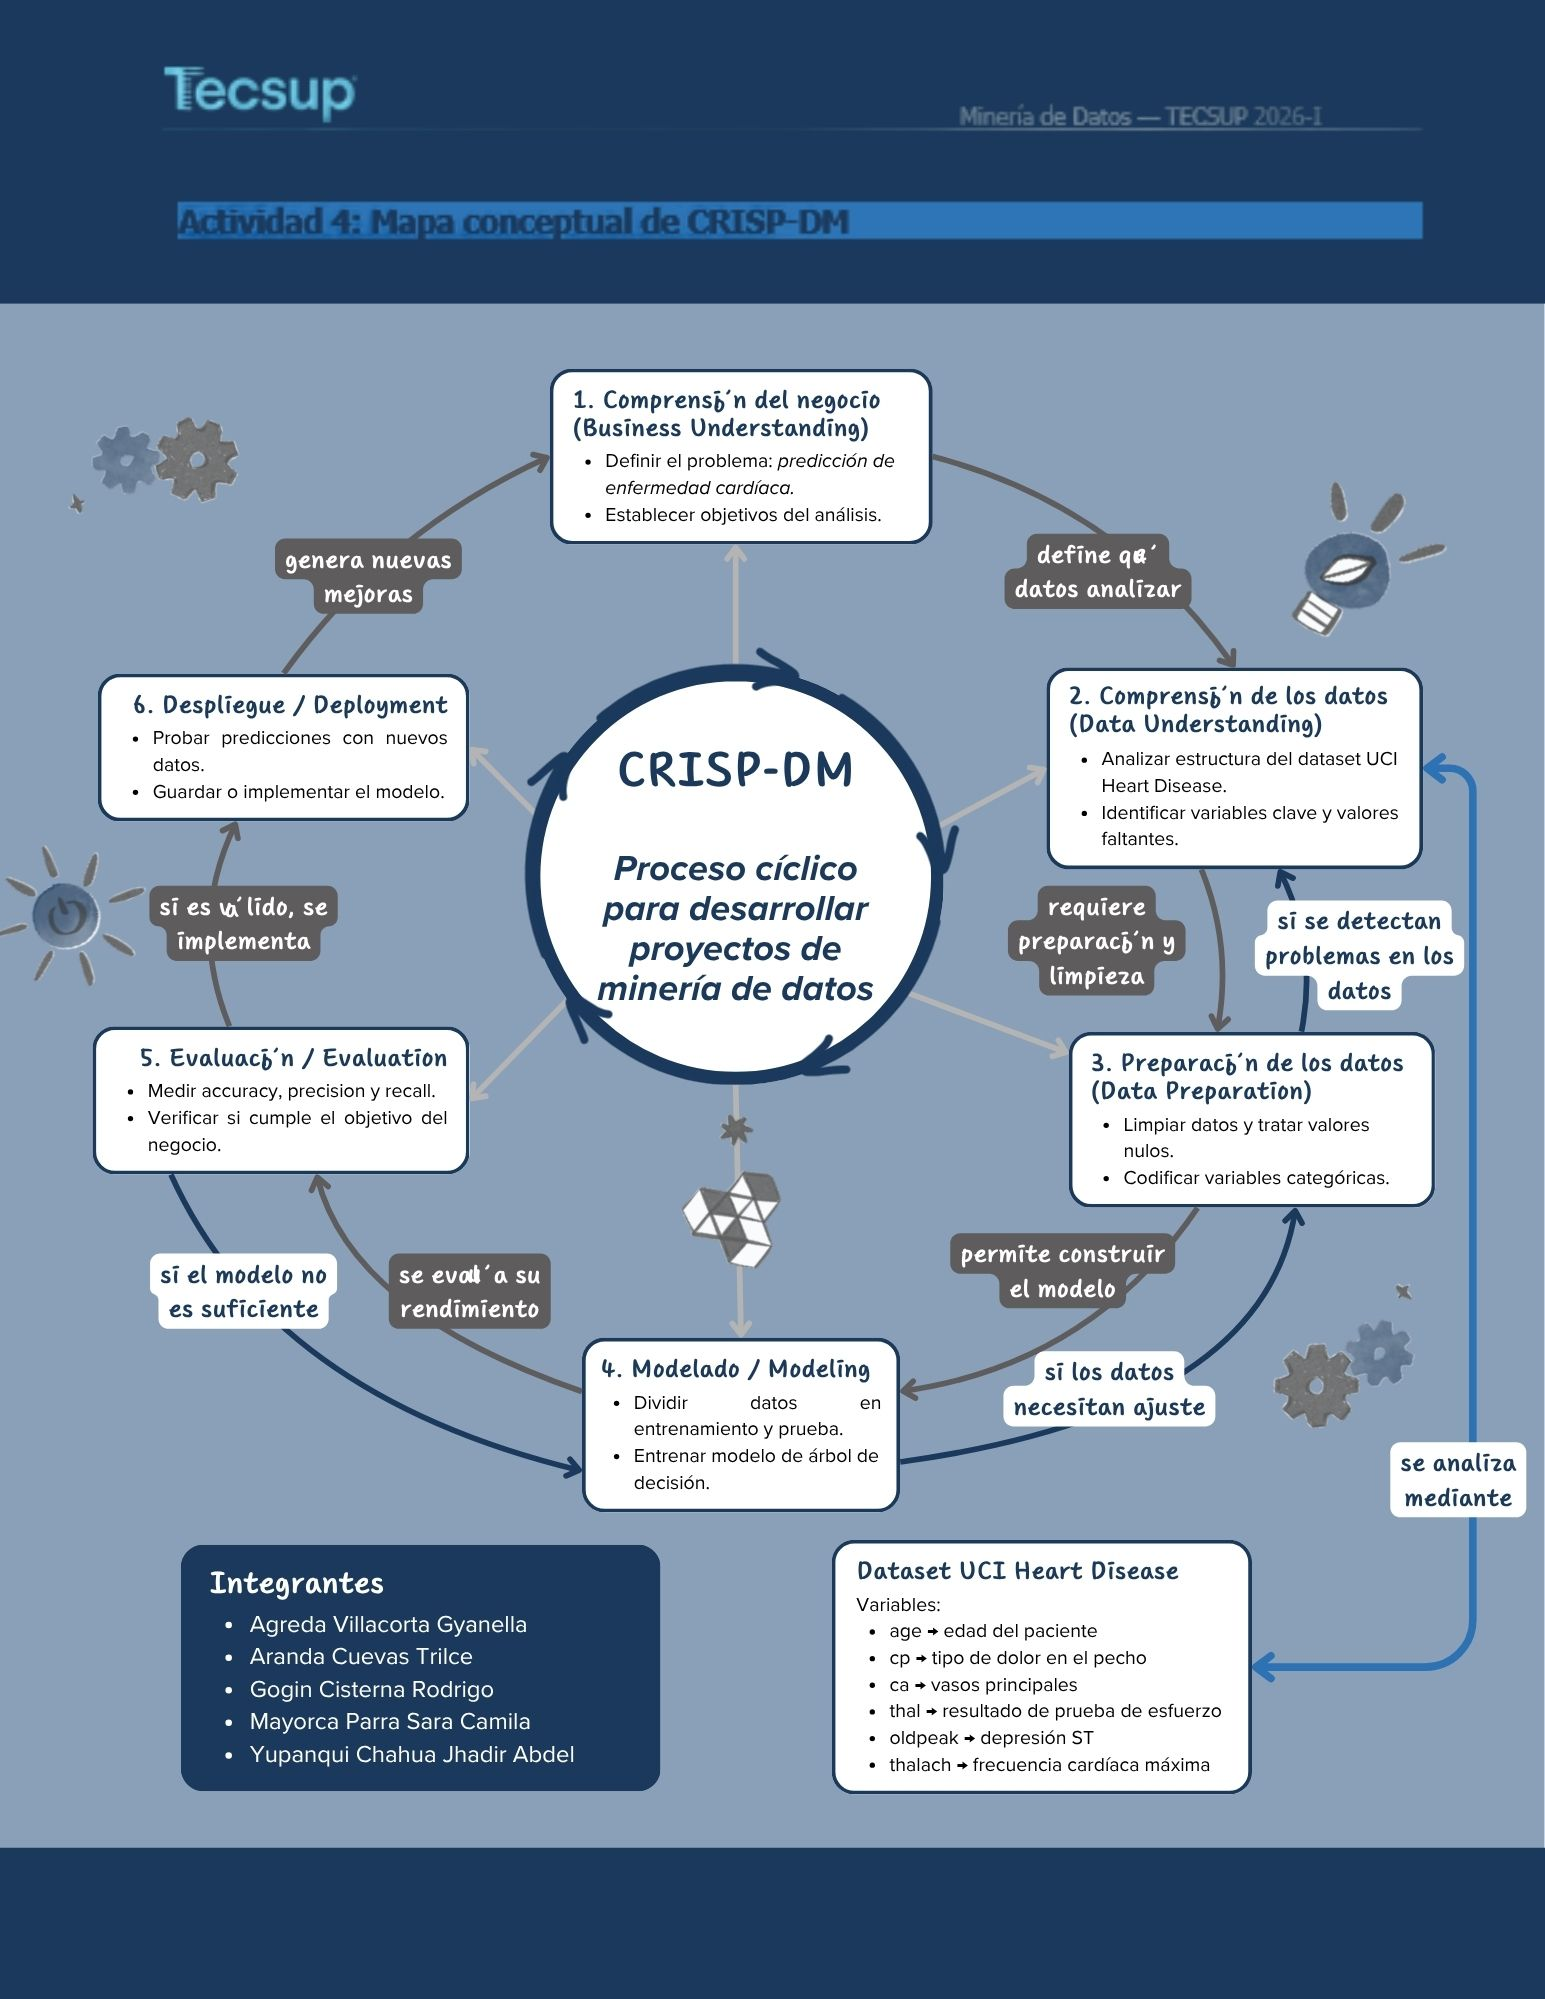

> **CONCLUSIONES**


•	La conclusión técnica más relevante es que el modelo de Árbol de Decisión no solo alcanzó una exactitud competitiva del 78.9%, sino que logró identificar patrones con alta coherencia médica. Variables como el tipo de dolor torácico (cp) y el número de vasos coloreados (ca) resultaron ser los predictores con mayor ganancia de información. Esto demuestra que la minería de datos, cuando se aplica correctamente sobre un dataset clínico, es capaz de replicar la jerarquía de síntomas que un especialista consideraría crítica para un diagnóstico de riesgo coronario.

•	Aprendimos que la calidad del modelo final depende directamente del tratamiento previo de los datos. La implementación de imputación por mediana para los valores nulos en ca y thal, sumada a la expansión de dimensiones mediante One-Hot Encoding, fue lo que permitió que el algoritmo procesara la información sin sesgos jerárquicos erróneos. Sin esta fase de "limpieza y traducción", el modelo habría tenido un rendimiento significativamente inferior, lo que nos enseña que el éxito en Ciencia de Datos reside un 80% en la preparación y un 20% en el modelado.

•	Desde una perspectiva de aprendizaje estratégico, concluimos que en salud no basta con tener un "Accuracy" alto; es vital analizar la Matriz de Confusión. En nuestro proyecto, lograr un equilibrio donde los falsos negativos se mantuvieran bajo control fue la prioridad, ya que omitir un caso de riesgo es mucho más costoso humanamente que realizar una prueba adicional por un falso positivo. Esta experiencia nos enseñó a evaluar modelos no solo como números, sino bajo el contexto del problema real que intentamos resolver.
